<a href="https://colab.research.google.com/github/stephenchen0814/04-LinearReg_Salary/blob/main/Music%20Genre%20Classification-Final%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# imports all relevant packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch
import torch.nn as nn
from torch import optim
from sklearn import svm
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder,RobustScaler
from sklearn.metrics import confusion_matrix
from sklearn.multiclass import OneVsOneClassifier
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
import pandas as pd
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [27]:
train_path=("train.csv")
test_path=("test.csv")

In [28]:
train_df = pd.read_csv(train_path)
train_df

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,6
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,5
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17991,Green-House,Find Home,35.0,0.166,0.109,7.0,-17.100,0,0.0413,0.993000,0.824000,0.0984,0.1770,171.587,193450.0,3,6
17992,Micatone,All Gone,27.0,0.638,0.223,11.0,-10.174,0,0.0329,0.858000,0.000016,0.0705,0.3350,73.016,257067.0,4,2
17993,Smash Hit Combo,Peine perdue,34.0,0.558,0.981,4.0,-4.683,0,0.0712,0.000030,0.000136,0.6660,0.2620,105.000,216222.0,4,8
17994,Beherit,Salomon's Gate,29.0,0.215,0.805,6.0,-12.757,0,0.1340,0.001290,0.916000,0.2560,0.3550,131.363,219693.0,4,8


In [29]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         17996 non-null  object 
 1   Track Name          17996 non-null  object 
 2   Popularity          17568 non-null  float64
 3   danceability        17996 non-null  float64
 4   energy              17996 non-null  float64
 5   key                 15982 non-null  float64
 6   loudness            17996 non-null  float64
 7   mode                17996 non-null  int64  
 8   speechiness         17996 non-null  float64
 9   acousticness        17996 non-null  float64
 10  instrumentalness    13619 non-null  float64
 11  liveness            17996 non-null  float64
 12  valence             17996 non-null  float64
 13  tempo               17996 non-null  float64
 14  duration_in min/ms  17996 non-null  float64
 15  time_signature      17996 non-null  int64  
 16  Clas

In [30]:
train_df.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,17568.000000,17996.000000,17996.000000,15982.000000,17996.000000,17996.000000,17996.000000,17996.000000,13619.000000,17996.000000,17996.000000,17996.000000,1.799600e+04,17996.000000,17996.000000
mean,44.512124,0.543433,0.662777,5.952447,-7.910660,0.636753,0.079707,0.247082,0.177562,0.196170,0.486208,122.623294,2.007445e+05,3.924039,6.695821
std,17.426928,0.166268,0.235373,3.196854,4.049151,0.480949,0.083576,0.310632,0.304048,0.159212,0.240195,29.571527,1.119891e+05,0.361618,3.206073
min,1.000000,0.059600,0.000020,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.018300,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.509000,3.000000,-9.538000,0.000000,0.034800,0.004300,0.000089,0.097500,0.297000,99.620750,1.663370e+05,4.000000,5.000000
50%,44.000000,0.545000,0.700000,6.000000,-7.016000,1.000000,0.047400,0.081400,0.003910,0.129000,0.481000,120.065500,2.091600e+05,4.000000,8.000000
75%,56.000000,0.659000,0.860000,9.000000,-5.189000,1.000000,0.083000,0.434000,0.200000,0.258000,0.672000,141.969250,2.524900e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.355000,1.000000,0.955000,0.996000,0.996000,1.000000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


In [31]:
train_df.isna().sum()

,0
Artist Name,0
Track Name,0
Popularity,428
danceability,0
energy,0
key,2014
loudness,0
mode,0
speechiness,0
acousticness,0


In [32]:
train_df.columns

Index(['Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_in min/ms', 'time_signature', 'Class'],
      dtype='object')

In [33]:
data_columns =['Popularity', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_in min/ms', 'time_signature']
data_columns

['Popularity',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_in min/ms',
 'time_signature']

In [34]:
train_num=train_df.loc[:,data_columns]
imp_median = SimpleImputer(strategy='median')
train_num.iloc[:,:]=imp_median.fit_transform(train_num.iloc[:,:])
train_num.isna().sum()

,0
Popularity,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0


In [35]:
y = train_df.loc[:,'Class']
y

,Class
0,5
1,10
2,6
3,5
4,10
...,...
17991,6
17992,2
17993,8
17994,8


In [36]:
sc=StandardScaler()

train_num.iloc[:,:]=sc.fit_transform(train_num.iloc[:,:])
train_num

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,0.900217,1.867915,-0.419671,-1.645675,0.727743,0.755294,-0.373407,-0.740387,-0.478253,-0.698900,1.718614,0.387130,0.302284,0.210065
1,0.551747,-0.970946,0.642500,-0.981798,0.168104,0.755294,-0.467934,-0.791896,-0.477889,-0.597774,0.344694,-0.208629,0.455312,0.210065
2,-0.551741,-0.658190,-0.207237,0.014018,-0.104553,0.755294,-0.325545,0.769157,-0.491769,1.242595,1.252314,0.847383,-0.813293,0.210065
3,1.248687,1.861901,-0.279465,1.341773,0.341479,-1.323988,-0.289648,-0.727188,-0.478253,-0.465870,0.344694,-0.527221,-0.239105,0.210065
4,0.493669,-2.264071,1.326539,-1.313736,0.896919,0.755294,1.630811,-0.794893,-0.433891,-0.151814,-1.642078,2.584879,0.260886,0.210065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17991,-0.551741,-2.270086,-2.352824,0.345957,-2.269512,-1.323988,-0.459558,2.401358,2.506239,-0.614105,-1.287357,1.655818,-0.065137,-2.555361
17992,-1.016367,0.568775,-1.868474,1.673711,-0.558982,-1.323988,-0.560068,1.966748,-0.492424,-0.789348,-0.629541,-1.677582,0.502943,0.210065
17993,-0.609819,0.087612,1.352031,-0.649859,0.797142,-1.323988,-0.101790,-0.795342,-0.491987,2.951060,-0.933469,-0.595971,0.138210,0.210065
17994,-0.900210,-1.975373,0.604262,0.014018,-1.196911,-1.323988,0.649642,-0.791285,2.841048,0.375800,-0.546273,0.295553,0.169205,0.210065


In [37]:
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm

def plot_cv_indices(cv, X, y, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""

    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=None)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='_', lw=lw, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

    # Plot the data classes and groups at the end
    ax.scatter(range(len(X)), [ii + 1.5] * len(X),
               c=y, marker='_', lw=lw, cmap=cmap_data)

    # Formatting
    yticklabels = list(range(n_splits)) + ['class']
    ax.set(yticks=np.arange(n_splits+1) + .5, yticklabels=yticklabels,
           xlabel='Sample index', ylabel="CV iteration",
           ylim=[n_splits+1.2, -.1], xlim=[0, X.shape[0]])
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

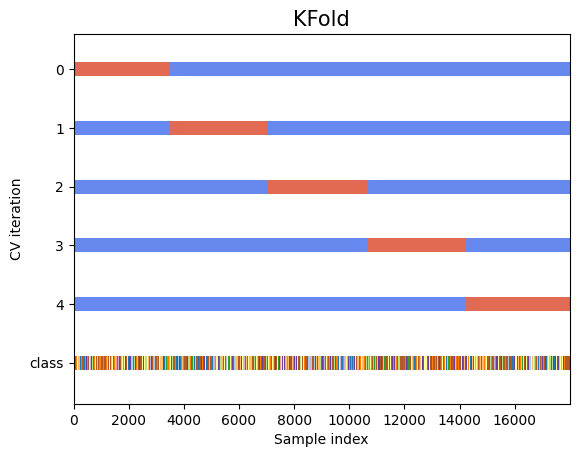

In [38]:
cv = KFold(5)

fig, ax = plt.subplots()
plot_cv_indices(cv, train_df, y, ax, n_splits = 5)
plt.show()

In [39]:
svm_models = []
for ii, (tr, tt) in enumerate(cv.split(X=train_num, y=y, groups=None)):
    # Fill in indices with the training/test groups
    train = train_num.iloc[tr,:]
    val = train_num.iloc[tt,:]
    train_y = y.iloc[tr]
    val_y = y.iloc[tt]
    svm_model = svm.SVC(kernel='linear')
    svm_model.fit(train, train_y)
    svm_models.append(svm_model)
    print(svm_model.score(val, val_y))

0.515
0.4909697138093915
0.486246179494304
0.4901361489302584
0.49736037788274523


In [40]:
svm_model1=svm.SVC(kernel='linear')
svm_model1.fit(train_num, y)

SVC(kernel='linear')

In [41]:
knn_models = []
for ii, (tr, tt) in enumerate(cv.split(X=train_num, y=y, groups=None)):
    # Fill in indices with the training/test groups
    train = train_num.iloc[tr,:]
    val = train_num.iloc[tt,:]
    train_y = y.iloc[tr]
    val_y = y.iloc[tt]
    knn_model = KNeighborsClassifier()
    knn_model.fit(train, train_y)
    knn_models.append(knn_model)
    print(knn_model.score(val, val_y))

0.445
0.42928591275354266
0.41455959988885804
0.43262017227007504
0.42845234787440956


In [42]:
rf_classifiers = []
for ii, (tr, tt) in enumerate(cv.split(X=train_num, y=y, groups=None)):
    # Fill in indices with the training/test groups
    train = train_num.iloc[tr,:]
    val = train_num.iloc[tt,:]
    train_y = y.iloc[tr]
    val_y = y.iloc[tt]
    #print(train.shape, val.shape, train_y.shape, val_y.shape)
    rf_classifier = RandomForestClassifier(n_estimators=100,                         # number of trees
                                       criterion='gini',
                                       max_samples=int(train.shape[0]*0.8),   # amount of samples in each tree
                                       max_depth=10,
                                       max_features=None,                       # we are using all features
                                       oob_score=True,                          # out of bag accuracy score
                                       random_state=42)
    rf_classifier.fit(train, train_y)
    rf_classifiers.append(rf_classifier)
    print(rf_classifier.score(val, val_y))

0.5380555555555555
0.5354265073631564
0.5254237288135594
0.5115309808280077
0.5276465684912476


In [43]:
input_size = 14
hidden_sizes = [20, 26, 20] #three hidden layers
output_size = 11


class DigitMLP(nn.Module):

    def __init__(self):
        super(DigitMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size,hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[2], output_size),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [44]:
y.unique()

array([ 5, 10,  6,  2,  4,  8,  9,  3,  7,  1,  0])

In [45]:
model = DigitMLP()
print(model)

n_epochs=3
lr=0.01

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum =0.9)

DigitMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=14, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=26, bias=True)
    (3): ReLU()
    (4): Linear(in_features=26, out_features=20, bias=True)
    (5): ReLU()
    (6): Linear(in_features=20, out_features=11, bias=True)
  )
)


In [46]:
def get_acc_loss(model, loader):
    correct=0
    total=0
    for images, labels in loader:
        output=model(images)
        pred = output.data.max(1, keepdim=True)[1]
        total+=labels.shape[0]
        correct += pred.eq(labels.data.view_as(pred)).sum()
        loss=loss_func(output, labels)
    acc=100.*correct/total
    return acc, loss

In [47]:
nn_models = []
for ii, (tr, tt) in enumerate(cv.split(X=train_num, y=y, groups=None)):
    # Fill in indices with the training/test groups
    train = train_num.iloc[tr,:]
    val = train_num.iloc[tt,:]
    train_y = y.iloc[tr]
    val_y = y.iloc[tt]

    model = DigitMLP()

    n_epochs=10
    lr=0.01
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum =0.9, weight_decay=0.001)

    train = torch.utils.data.TensorDataset(torch.tensor(train.values).float(), torch.tensor(train_y.values))
    val = torch.utils.data.TensorDataset(torch.tensor(val.values).float(), torch.tensor(val_y.values))
    trainloader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True)
    testloader = torch.utils.data.DataLoader(val, batch_size=64, shuffle=True)

    train_loss = []
    test_loss = []
    train_acc=[]
    test_acc=[]

    n=len(trainloader)
    print(f"training for fold {ii}:")
    for epoch in range(n_epochs):
        model.train()
        for idx, (images, labels) in enumerate(trainloader):
            optimizer.zero_grad()
            output = model(images)
            loss=loss_func(output, labels)
            loss.backward()
            optimizer.step()

            if (idx+1)%100==0:
                print(f'Epoch {epoch+1}/{n_epochs}, step {idx+1}/{n}, Loss={loss.item():.3}')

        model.eval()
        with torch.inference_mode():
            acc, loss = get_acc_loss(model, testloader)
            test_acc.append(acc)
            test_loss.append(loss)
            print(f'\nTest Accuracy = {acc}, Test Loss = {loss} \n')

            acc, loss = get_acc_loss(model, trainloader)
            train_acc.append(acc)
            train_loss.append(loss)

training for fold 0:
Epoch 1/10, step 100/225, Loss=2.32
Epoch 1/10, step 200/225, Loss=2.05

Test Accuracy = 28.94444465637207, Test Loss = 1.9879283905029297 

Epoch 2/10, step 100/225, Loss=1.71
Epoch 2/10, step 200/225, Loss=1.81

Test Accuracy = 38.52777862548828, Test Loss = 1.958752989768982 

Epoch 3/10, step 100/225, Loss=1.54
Epoch 3/10, step 200/225, Loss=1.37

Test Accuracy = 47.27777862548828, Test Loss = 1.495930790901184 

Epoch 4/10, step 100/225, Loss=1.44
Epoch 4/10, step 200/225, Loss=1.21

Test Accuracy = 46.75, Test Loss = 1.5535179376602173 

Epoch 5/10, step 100/225, Loss=1.15
Epoch 5/10, step 200/225, Loss=1.59

Test Accuracy = 50.38888931274414, Test Loss = 1.3654865026474 

Epoch 6/10, step 100/225, Loss=1.46
Epoch 6/10, step 200/225, Loss=1.48

Test Accuracy = 50.91666793823242, Test Loss = 1.1887868642807007 

Epoch 7/10, step 100/225, Loss=1.41
Epoch 7/10, step 200/225, Loss=1.2

Test Accuracy = 49.88888931274414, Test Loss = 1.048419713973999 

Epoch 8/10,

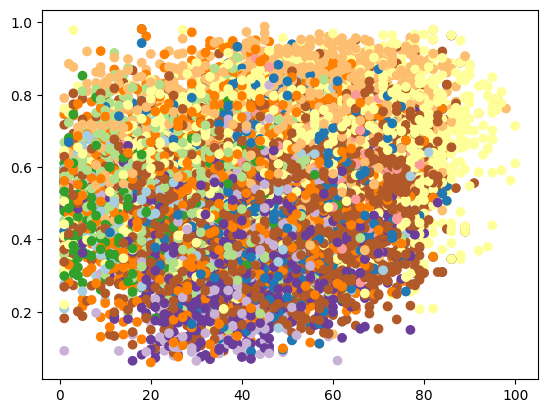

In [48]:
plt.scatter(train_df.Popularity, train_df.danceability, c = train_df.Class, cmap = cmap_data)

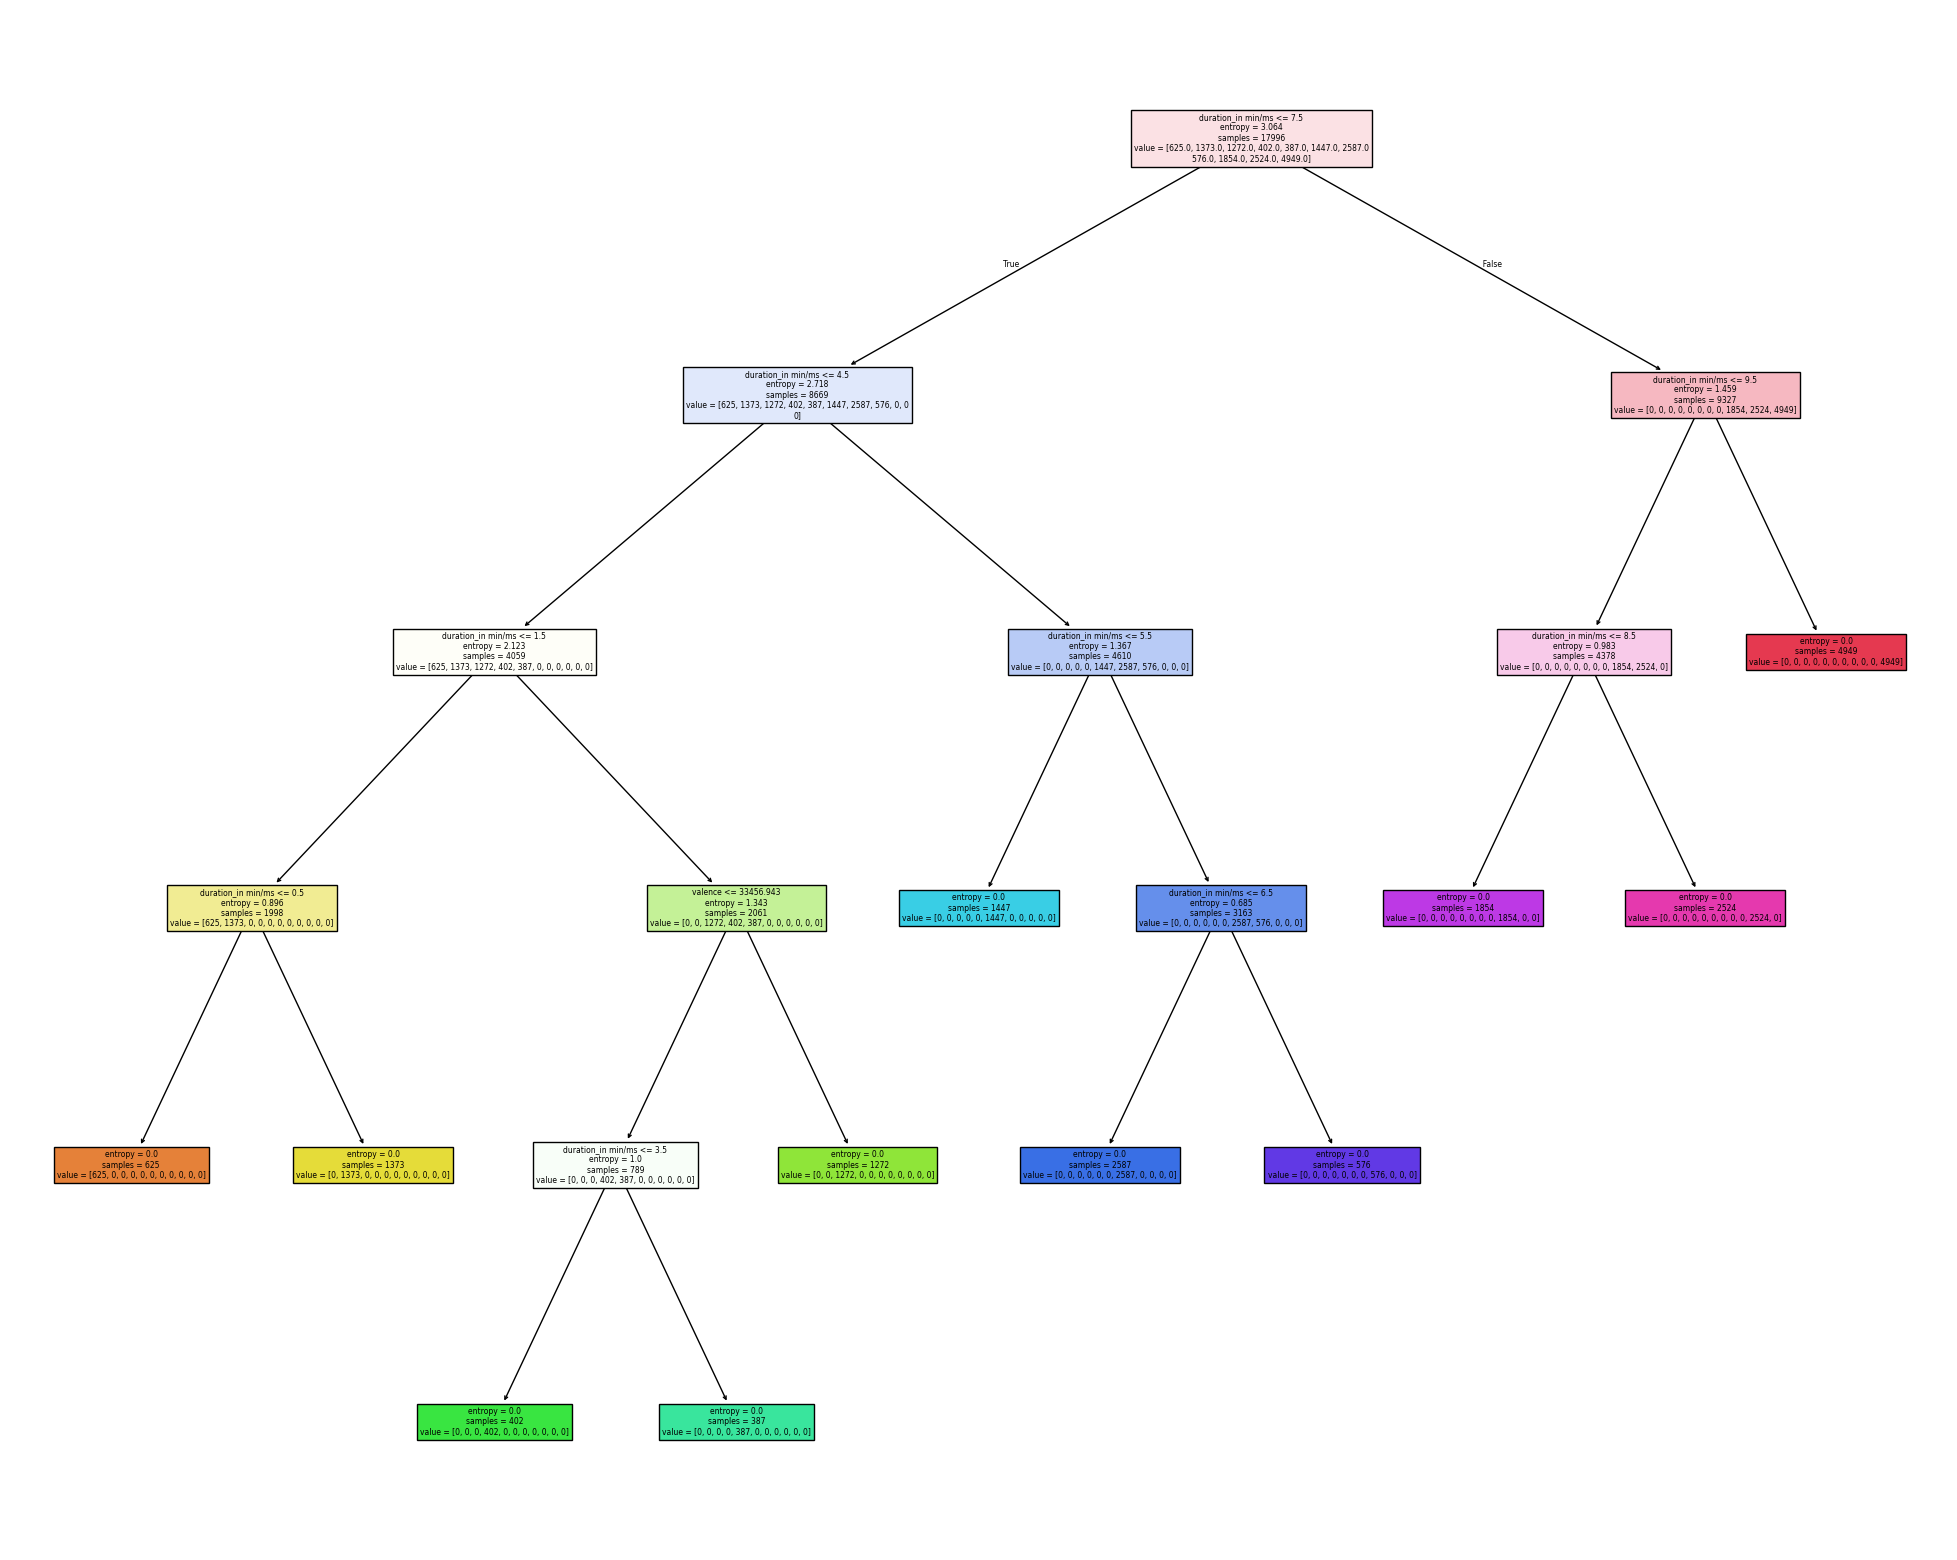

In [49]:
model = DecisionTreeClassifier(criterion = "entropy")
model.fit(train_df.iloc[:, 2:], y)

plt.figure(figsize = (25,20))
plot_tree(model, filled = True, feature_names = train_df.columns)

plt.show()

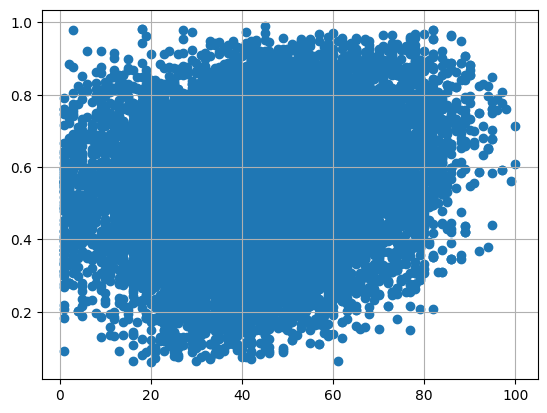

In [103]:
model = datasets.make_regression(n_samples=100, n_features=1, noise=20)

fig=plt.figure()
plt.grid()

plt.scatter(train_df.Popularity, train_df.danceability)

In [62]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [75]:
rf_regressor=RandomForestRegressor(n_estimators=10,
                                   max_samples=int(train_df.Popularity.shape[0]*0.8),
                                   min_impurity_decrease=0.1,
                                   max_depth=3,
                                   oob_score=True,
                                   random_state=42)

In [81]:
rf_regressor.fit(train_num[['Popularity']], train_num['danceability'])

RandomForestRegressor(max_depth=3, max_samples=14396, min_impurity_decrease=0.1,
                      n_estimators=10, oob_score=True, random_state=42)

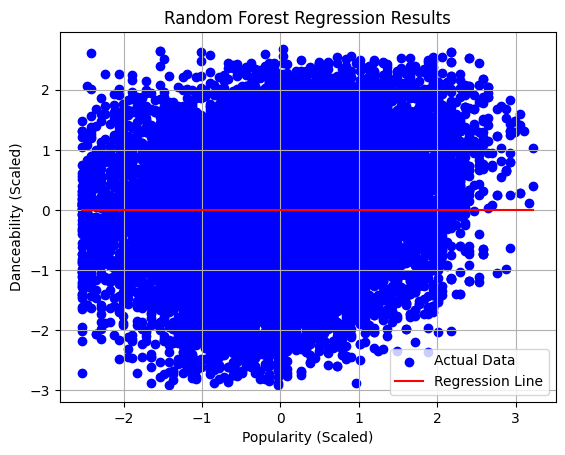

In [107]:
# Create a range of Popularity values for plotting the regression line
# Use the min and max of the actual scaled 'Popularity' from train_num
x_plot = np.linspace(train_num['Popularity'].min(), train_num['Popularity'].max(), 500).reshape(-1, 1)

# Plotting real points (scatter plot of actual data)
plt.scatter(train_num['Popularity'], train_num['danceability'], color='blue', label='Actual Data')

# Plotting the regression line
plt.plot(x_plot, rf_regressor.predict(x_plot), color='red', label='Regression Line')

plt.grid()
plt.title("Random Forest Regression Results")
plt.xlabel("Popularity (Scaled)")
plt.ylabel("Danceability (Scaled)")
plt.legend()
plt.show()

In [108]:
oob_score = rf_regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score:.2f}')

Out-of-Bag Score: -0.00
